# Chest X-Ray CNN

## Intro

This is a basic Convolutional Neural Network to diagnose chest x rays between 4 diagnoses. The limitations of such a model are immedietely apparent by limiting ourselves to only 4 diagnoses. However, it a near perfect diagnosis among the 4 it has learned.

It is worth noting that this is one of the first project that I attempted after learning ML. More advanced projects are available at my github (https://github.com/Ethan-Saline)

## Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score
)
from sklearn.utils import class_weight
import seaborn as sns

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)


## Download Data (only run this once)

In [ ]:
import kagglehub, shutil
path = kagglehub.dataset_download("jtiptj/chest-xray-pneumoniacovid19tuberculosis")
shutil.copytree(path, "../data", dirs_exist_ok=True)

## Parameters

In [3]:
BATCH_SIZE  = 32
NUM_EPOCHS  = 30
IMG_SIZE    = 128
NUM_CLASSES = 4
SEED        = 42
DATA_DIR    = "../data"


## Load Datasets

In [4]:
def make_dataset(split, shuffle=False):
    return tf.keras.preprocessing.image_dataset_from_directory(
        os.path.join(DATA_DIR, split),
        labels='inferred',
        label_mode='int',
        color_mode='rgb',
        batch_size=BATCH_SIZE,
        image_size=(IMG_SIZE, IMG_SIZE),
        shuffle=shuffle,
        seed=SEED,
    )

train_ds = make_dataset('train', shuffle=True)
val_ds   = make_dataset('val')
test_ds  = make_dataset('test')

class_names = test_ds.class_names
print("Classes:", class_names)


Found 6326 files belonging to 4 classes.
Found 38 files belonging to 4 classes.
Found 771 files belonging to 4 classes.
Classes: ['COVID19', 'NORMAL', 'PNEUMONIA', 'TURBERCULOSIS']


## Preprocessing & Augmentation

In [5]:
augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.2),
], name="augmentation")

def preprocess(images, labels, training=False):
    """Convert to grayscale, normalise, and optionally augment."""
    gray = tf.image.rgb_to_grayscale(images)        # (B, H, W, 1)
    norm = tf.cast(gray, tf.float32) / 255.0
    if training:
        norm = augmentation(norm, training=True)
    return norm, labels

AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    train_ds
    .map(lambda x, y: preprocess(x, y, training=True), num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(AUTOTUNE)
)
val_ds = (
    val_ds
    .map(lambda x, y: preprocess(x, y, training=False), num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(AUTOTUNE)
)
test_ds = (
    test_ds
    .map(lambda x, y: preprocess(x, y, training=False), num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)


## Visualise Some Preprocessed Samples

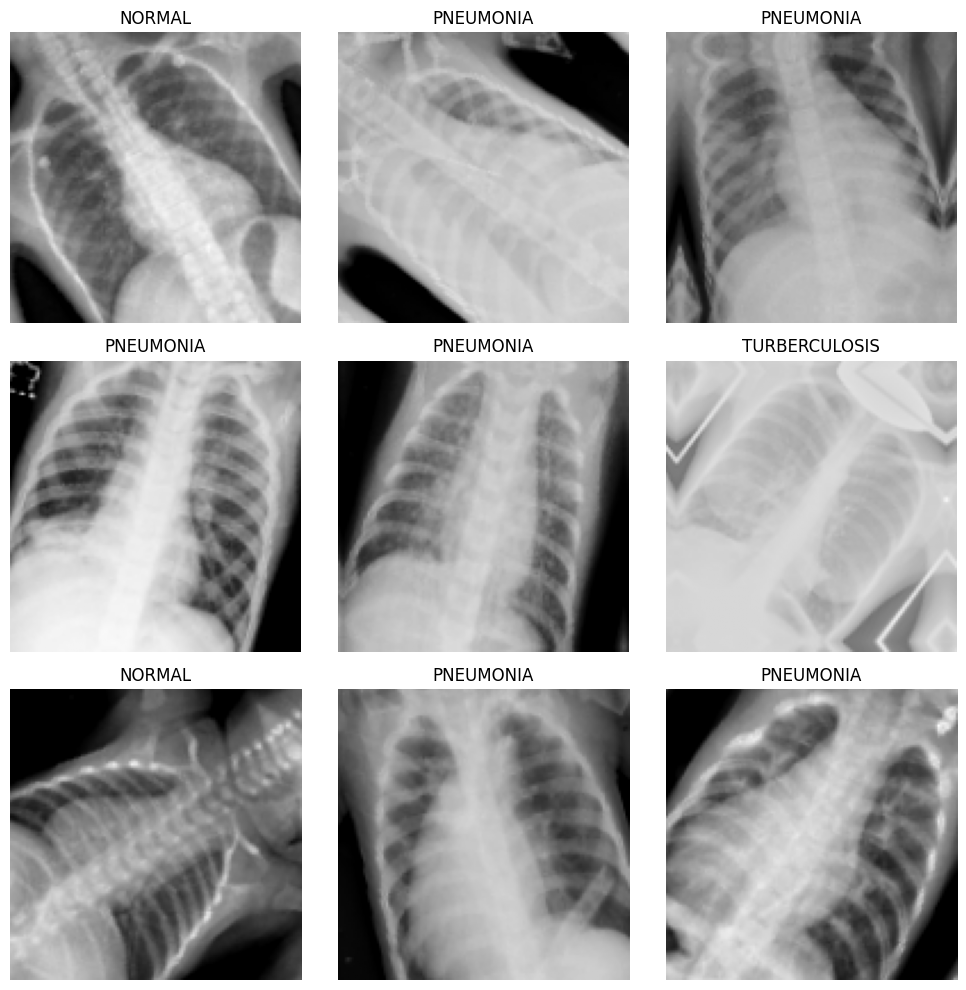

In [6]:
for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(tf.squeeze(images[i]), cmap="gray", vmin=0, vmax=1)
        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")
    plt.tight_layout()
    plt.show()
    break


## Class Weights

In [7]:
# Compute class weights from a raw (un-augmented) pass over the training labels
# so the weights are not influenced by the augmentation pipeline.
raw_train_ds = make_dataset('train', shuffle=False)
all_labels = np.concatenate([y.numpy() for _, y in raw_train_ds])

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(all_labels),
    y=all_labels,
)
class_weights_dict = dict(enumerate(weights))
print("Class weights:", {class_names[k]: round(v, 3) for k, v in class_weights_dict.items()})


Found 6326 files belonging to 4 classes.
Class weights: {'COVID19': np.float64(3.438), 'NORMAL': np.float64(1.179), 'PNEUMONIA': np.float64(0.408), 'TURBERCULOSIS': np.float64(2.433)}


## Model

In [8]:
l2 = regularizers.l2(1e-4)

model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1)),

    # Block 1 — 128 -> 64
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', kernel_regularizer=l2),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    # Block 2 — 64 -> 32
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=l2),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    # Block 3 — 32 -> 16
    layers.Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=l2),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    # Dense head — flatten preserves spatial features important for X-ray localisation
    layers.Flatten(),
    layers.Dropout(0.4),
    layers.Dense(256, activation='relu', kernel_regularizer=l2),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu', kernel_regularizer=l2),
    layers.Dense(NUM_CLASSES, activation='softmax'),
], name="covid_cnn")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

model.summary()


Model: "covid_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,515,844 (32.49 MB)

 Trainable params: 8,515,396 (32.48 MB)

 Non-trainable params: 448 (1.75 KB)

## Train

In [ ]:
cb_list = [
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1
    ),
    callbacks.EarlyStopping(
        monitor='val_loss', patience=8, restore_best_weights=True, verbose=1
    ),
    callbacks.ModelCheckpoint(
        'best_cnn.keras', monitor='val_accuracy', save_best_only=True, verbose=1
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=NUM_EPOCHS,
    class_weight=class_weights_dict,
    callbacks=cb_list,
)


Epoch 1/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 0s 985ms/step - accuracy: 0.5415 - loss: 3.9255
Epoch 1: val_accuracy improved from None to 0.15789, saving model to best_covid_cnn.keras

Epoch 1: finished saving model to best_covid_cnn.keras
198/198 ━━━━━━━━━━━━━━━━━━━━ 202s 993ms/step - accuracy: 0.6009 - loss: 2.7465 - val_accuracy: 0.1579 - val_loss: 12.6075 - learning_rate: 0.0010
Epoch 2/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 0s 965ms/step - accuracy: 0.6640 - loss: 1.5626
Epoch 2: val_accuracy improved from 0.15789 to 0.36842, saving model to best_covid_cnn.keras

Epoch 2: finished saving model to best_covid_cnn.keras
198/198 ━━━━━━━━━━━━━━━━━━━━ 192s 971ms/step - accuracy: 0.7011 - loss: 1.3464 - val_accuracy: 0.3684 - val_loss: 6.1546 - learning_rate: 0.0010
Epoch 3/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 0s 979ms/step - accuracy: 0.7473 - loss: 1.0132
Epoch 3: val_accuracy improved from 0.36842 to 0.42105, saving model to best_covid_cnn.keras

Epoch 3: finished saving model to best_covid_cnn.keras
1

## Training Curves

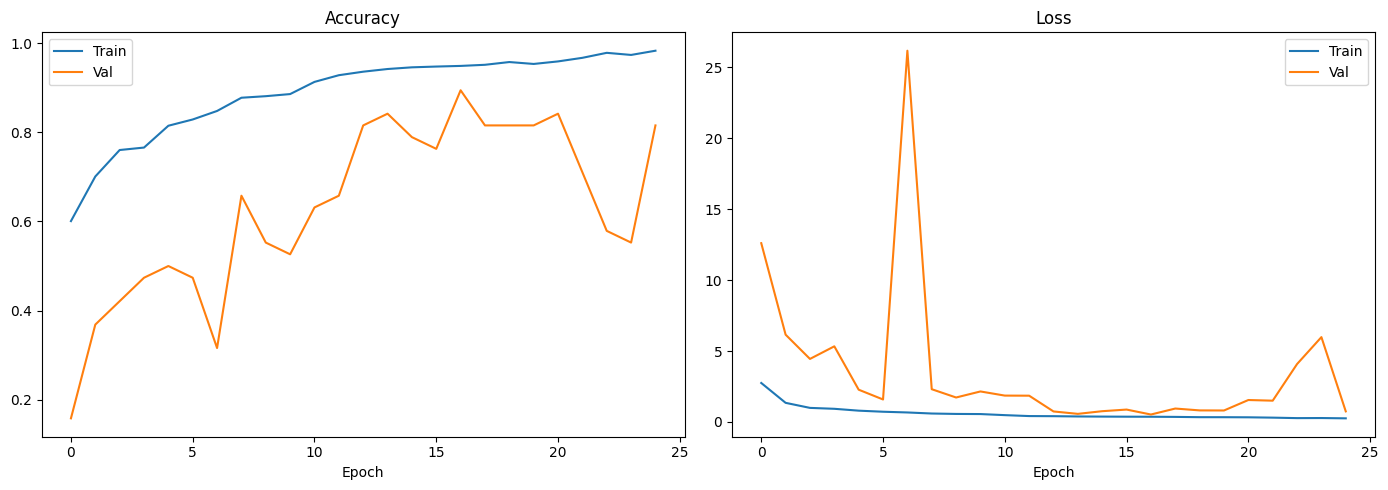

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, title in zip(axes, ['accuracy', 'loss'], ['Accuracy', 'Loss']):
    ax.plot(history.history[metric],          label='Train')
    ax.plot(history.history[f'val_{metric}'], label='Val')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()

plt.tight_layout()
plt.show()


## Evaluate on Test Set

In [11]:
y_true = np.concatenate([y.numpy() for _, y in test_ds])
y_pred = np.argmax(model.predict(test_ds), axis=1)

print(f"Test accuracy: {accuracy_score(y_true, y_pred):.4f}\n")
print(classification_report(y_true, y_pred, target_names=class_names))


25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 207ms/step
Test accuracy: 0.8936

               precision    recall  f1-score   support

      COVID19       0.95      0.92      0.93       106
       NORMAL       0.88      0.80      0.84       234
    PNEUMONIA       0.88      0.94      0.91       390
TURBERCULOSIS       0.93      0.90      0.91        41

     accuracy                           0.89       771
    macro avg       0.91      0.89      0.90       771
 weighted avg       0.89      0.89      0.89       771



## Confusion Matrix

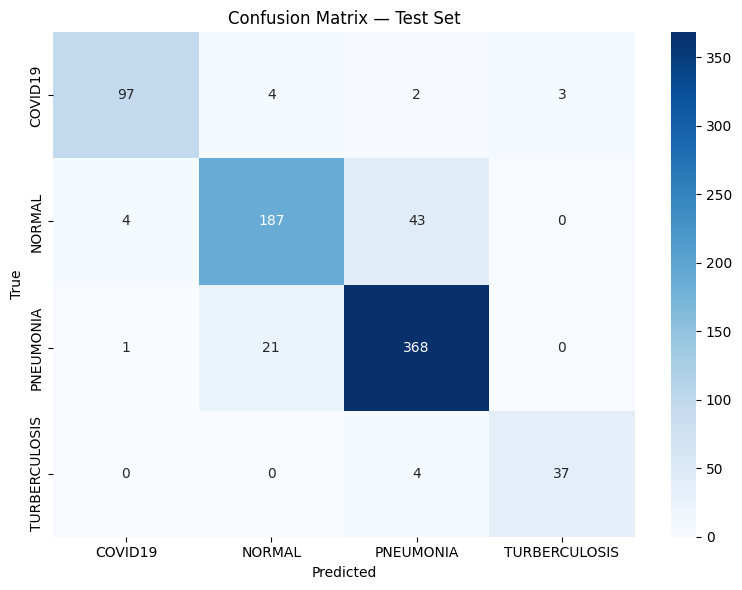

In [12]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names
)
plt.title('Confusion Matrix — Test Set')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()
